In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score

In [4]:
# Load dataset
# The Wine dataset is a popular benchmark dataset in machine learning.
# It contains 178 samples of wines that come from 3 different cultivars (classes) grown in the same region of Italy.
# Each wine sample is described by 13 chemical features, measured from chemical analysis of the wine.
df = pd.read_csv("wine_clustering.csv")

In [8]:
# Drop non-numeric columns if necessary
#df.iloc[:, 0] accesses the first column.
#np.issubdtype(df.iloc[:, 0], np.number) checks if the first column is numeric.
#If the first column is not numeric (likely categorical like labels), it is removed by selecting all other columns (df.iloc[:, 1:]).
if not np.issubdtype(df.iloc[:, 0], np.number):
    df = df.iloc[:, 1:]

print(df.head())  # Display the first five rows to inspect the dataset

   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD280  Proline  
0   3.92     1065  
1   3.40     1050  
2   3.17     1185  
3   3.45    

In [9]:
# Identify the alcohol column
#If the dataset has a column named "alcohol", it is assigned to alcohol_col.
#If not, the first column is assumed to represent alcohol content.
alcohol_col = "alcohol" if "alcohol" in df.columns else df.columns[0]  # Assuming first column if unknown

print(df[alcohol_col].head()) # Print the first few alcohol values for verification

0    14.23
1    13.20
2    13.16
3    14.37
4    13.24
Name: Alcohol, dtype: float64


In [10]:
# Standardize features
#StandardScaler scales all features so they have a mean of 0 and a standard deviation of 1.
#This helps improve clustering performance by making all features comparable.
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

In [11]:
# Fit GMM with 2 clusters (high vs. low alcohol)
#GaussianMixture(n_components=2) creates a model with 2 clusters (one for high-alcohol wines, one for low-alcohol wines).
#gmm.fit(df_scaled) trains the model on the standardized data.
#gmm.predict(df_scaled) assigns each data point to a cluster (0 or 1).
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(df_scaled)
labels = gmm.predict(df_scaled)
df["Cluster"] = labels #Adds a new column "Cluster" to df, where each row is labeled as either 0 or 1.

In [12]:
#The mapping of 0 and 1 in the Cluster column depends on the mean alcohol content within each cluster. 
#The script determines which cluster corresponds to High Alcohol and which corresponds to Low Alcohol.
#cluster_means computes the average alcohol content for each cluster (0 and 1).
#idxmax() finds the cluster with the highest average alcohol content (assigned as High Alcohol).
#idxmin() finds the cluster with the lowest average alcohol content (assigned as Low Alcohol).
#The mapping is dynamically assigned based on the data, so you should check df.groupby("Cluster")[alcohol_col].mean() to verify.
if alcohol_col in df.columns:
    cluster_means = df.groupby("Cluster")[alcohol_col].mean()
    high_alcohol_cluster = cluster_means.idxmax()
    low_alcohol_cluster = cluster_means.idxmin()
    df["Alcohol Type"] = df["Cluster"].map({high_alcohol_cluster: "High Alcohol", low_alcohol_cluster: "Low Alcohol"})
else:
    print("Warning: Alcohol column not found, cluster assignment may be incorrect.")

print(cluster_means)

Cluster
0    13.042589
1    12.929394
Name: Alcohol, dtype: float64


In [13]:
#Compute silhouette score
sil_score = silhouette_score(df_scaled, labels)
print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.3004


In [14]:
# Perform PCA for visualization
#PCA reduces high-dimensional data to two dimensions for visualization.
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Get feature contributions to PCA components
pca_components = pd.DataFrame(pca.components_, columns=df.columns[:-2], index=["PC1", "PC2"])

# Find top contributing features for PC1 and PC2
top_pc1_feature = pca_components.T.abs().idxmax()["PC1"]
top_pc2_feature = pca_components.T.abs().idxmax()["PC2"]

In [15]:
# Display the top contributing features for each principal component
print("\nTop Contributing Features for PC1:")
print(pca_components.T.abs()[["PC1"]].sort_values(by="PC1", ascending=False).head(5))

print("\nTop Contributing Features for PC2:")
print(pca_components.T.abs()[["PC2"]].sort_values(by="PC2", ascending=False).head(5))



Top Contributing Features for PC1:
                           PC1
OD280                 0.473492
Flavanoids            0.414590
Total_Phenols         0.395071
Nonflavanoid_Phenols  0.333109
Proline               0.286862

Top Contributing Features for PC2:
                      PC2
Alcohol          0.550884
Color_Intensity  0.519707
Proline          0.443888
Hue              0.237206
Malic_Acid       0.227391


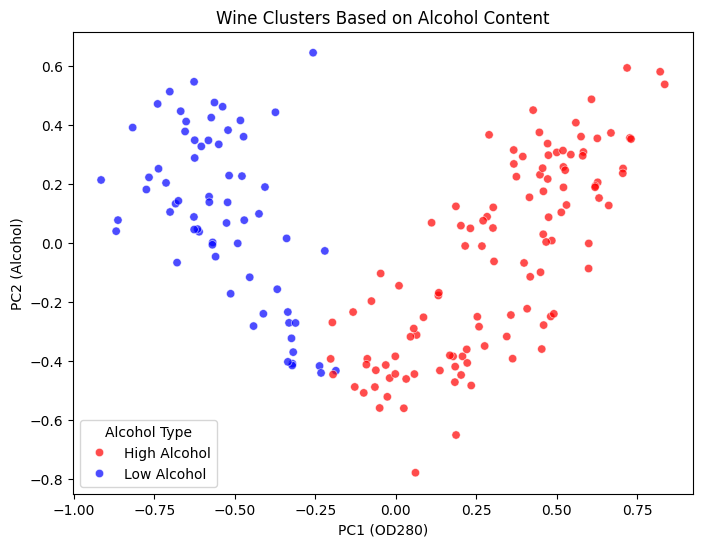

In [16]:
# Scatter plot of clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=df["Alcohol Type"], 
                palette={"High Alcohol": "red", "Low Alcohol": "blue"}, alpha=0.7)
plt.xlabel(f"PC1 ({top_pc1_feature})")  # Labels PC1 with its most important feature
plt.ylabel(f"PC2 ({top_pc2_feature})")  # Labels PC2 with its most important feature
plt.title("Wine Clusters Based on Alcohol Content")
plt.legend(title="Alcohol Type")
plt.show()